<a href="https://colab.research.google.com/github/sanchezromeroaday-web/Computacional/blob/main/Copy_of_Voluntario2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación del Modelo de Ising en 2D mediante el Método de Monte Carlo
**Informe de Física Computacional**

**Aday Sánchez Romero** **Lenguaje de núcleo:** C++ (Cálculo) y Python 3.13.12 (Visualización)

---
## 1. Objetivos del Estudio

El objetivo principal de este trabajo es simular y estudiar las propiedades del modelo de Ising en dos dimensiones mediante la dinámica de Kawasaki. A continuación se enumeran las actividades y cálculos a realizar:

**Fase A: Magnetización Inicial Nula**
1. **Simulación y Visualización:** Simular la dinámica para varios valores de temperatura y representar varios fotogramas asociados a dichas temperaturas.
2. **Curva de Magnetización:** Obtener la curva de magnetización media por partícula calculada "por dominios" en función de la temperatura para varios tamaños del sistema (e.g., $N=32, 64, 128$). Este promedio se realiza calculando la magnetización en cada una de las mitades (superior e inferior) del sistema.
3. **Perfil de Densidad:** Calcular la densidad de partículas media en la dirección $y$ como función de la temperatura y para diferentes tamaños.
4. **Energía:** Calcular la energía media por partícula como función de la temperatura para los diferentes tamaños.
5. **Densidad Promedio:** Calcular la densidad de partículas promedio en la dirección $y$ para varias temperaturas.
6. **Calor Específico y Transición de Fase:** Calcular el calor específico a partir de las fluctuaciones de la energía:
   $$c_N = \frac{1}{N^2 T^2} [\langle E^2 \rangle - \langle E \rangle^2]$$
   Se estudiará su comportamiento con $N$ para extrapolar el valor de la temperatura crítica en el límite $N \to \infty$.
7. **Susceptibilidad Magnética:** Calcular la susceptibilidad magnética a partir de las fluctuaciones de la magnetización en cada dominio:
   $$\chi_N = \frac{1}{N^2 T} [\langle M^2 \rangle - \langle M \rangle^2]$$
   Se determinará la temperatura crítica extrapolando para $N \to \infty$.

**Fase B: Magnetización Inicial No Nula**
8. **Repetición General:** Realizar los puntos 1-6 anteriores partiendo de una magnetización $m_0 \neq 0$. El promedio por dominios se realizará promediando por separado la fracción inferior $x = (1+m_0)/2$ y la fracción superior $1-x$. Se representará la curva de magnetización frente a la temperatura para comprobar que es discontinua por debajo de una temperatura crítica.

---
## 2. Metodología: Conceptos Clave

Para simular este sistema sin tener que calcular el infinito número de estados posibles, utilizamos herramientas computacionales clave:

### El Método de Monte Carlo (Aceptación-Rechazo)
En lugar de evaluar absolutamente todas las configuraciones de la red, el método de **Monte Carlo** utiliza números aleatorios para tomar una "muestra representativa" del sistema.

El concepto de **Aceptación-Rechazo** funciona como un filtro: generamos configuraciones al azar y, mediante un criterio probabilístico, decidimos si esa configuración es válida para nuestro estudio (se acepta) o si se descarta (se rechaza).

---

### El Algoritmo de Metropolis
Es la regla de decisión que usamos para saber cómo evolucionan los espines con el tiempo y la temperatura. Funciona con esta lógica intuitiva:

1. **Elegimos un cambio en el sistema** y calculamos qué pasaría con la energía del sistema si lo aplicamos.
2. **Si el cambio reduce la energía**, el cambio es favorable y lo **aceptamos siempre**. El sistema tiende naturalmente al orden.
3. **Si el cambio aumenta la energía**, no lo rechazamos inmediatamente. Lo aceptamos con una **cierta probabilidad que depende de la temperatura**.
   * A **temperaturas altas**, el sistema acepta muchos cambios desfavorables (mucha agitación térmica y desorden).
   * A **temperaturas bajas**, es casi imposible aceptar un aumento de energía (el sistema se congela en un estado ordenado).

---

### Dinámica de Kawasaki
A diferencia de la dinámica de Glauber (spin-flip) explicada en teoría, la **dinámica de Kawasaki** introduce un cambio fundamental en la evolución temporal del sistema:

* **Mecanismo:** En lugar de invertir un solo espín, se escogen **un par de espines vecinos al azar** y se intercambian sus valores, aplicando la misma probabilidad dictada por el algoritmo de Metropolis.
* **Conservación:** Este mecanismo garantiza que la **magnetización inicial es conservada** por la dinámica a lo largo de toda la simulación.
* **Condiciones de Contorno:** Para facilitar la observación de los dominios magnéticos, se utilizan condiciones de contorno periódicas sólo en la dirección $x$ (columnas), mientras que se **fijan los espines en los bordes de la dirección $y$** (borde superior con espines negativos e inferior con positivos).
* **Transiciones de Fase:** * Partiendo de una magnetización nula, se obtiene una transición de fase continua por debajo de la temperatura crítica, formando dominios de aproximadamente igual tamaño.
  * Partiendo de una magnetización no nula, se produce una transición de fase discontinua, con coexistencia de dominios de distintos tamaños.

#1. Simulación y visualización

En este apartado vamos a analizar 4 fotogramas, distintos para la  temperatura de T=1.5 una temperatura pode debajo de la critica teórica, $T_c$. Posteriomente vamos a mostrar el último fotograma de 4 temeratureas diferentes (0.1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import io

# ========================================
# Parámetros
# ========================================
file_in = "ising_kawasaki.dat" # El archivo que genera tu C++

# Indica aquí qué números de iteración quieres guardar.
fotogramas_a_guardar = [10000] #----- Cambiar o añadir fotogramas

# ========================================
# Lectura del fichero de datos
# ========================================
with open(file_in, "r") as f:
    data_str = f.read()

frames_data = list()
for frame_data_str in data_str.split("\n\n"):
    if frame_data_str.strip(): # Comprobación para evitar fallos con líneas vacías
        frame_data = np.loadtxt(io.StringIO(frame_data_str), delimiter=",")
        frames_data.append(frame_data)

# ========================================
# Generación de imágenes PDF
# ========================================
for idx in fotogramas_a_guardar:
    # Nos aseguramos de que el fotograma que pides realmente existe
    if idx < len(frames_data):
        fig, ax = plt.subplots()
        ax.axis("off")  # Ocultar los ejes

        # Representar con el mapa de color morado
        ax.imshow(frames_data[idx], cmap="Purples", vmin=-1, vmax=+1)

        # Guardar la imagen en PDF recortando los márgenes blancos extra
        nombre_archivo = f"fotograma_4.0{idx}.png"
        fig.savefig(nombre_archivo, bbox_inches='tight', dpi=150)
        plt.close(fig) # Cerrar la figura para liberar memoria

        print(f"Éxito: Se ha guardado {nombre_archivo}")
    else:
        print(f"Aviso: El fotograma {idx} no existe. El archivo solo tiene {len(frames_data)} fotogramas.")

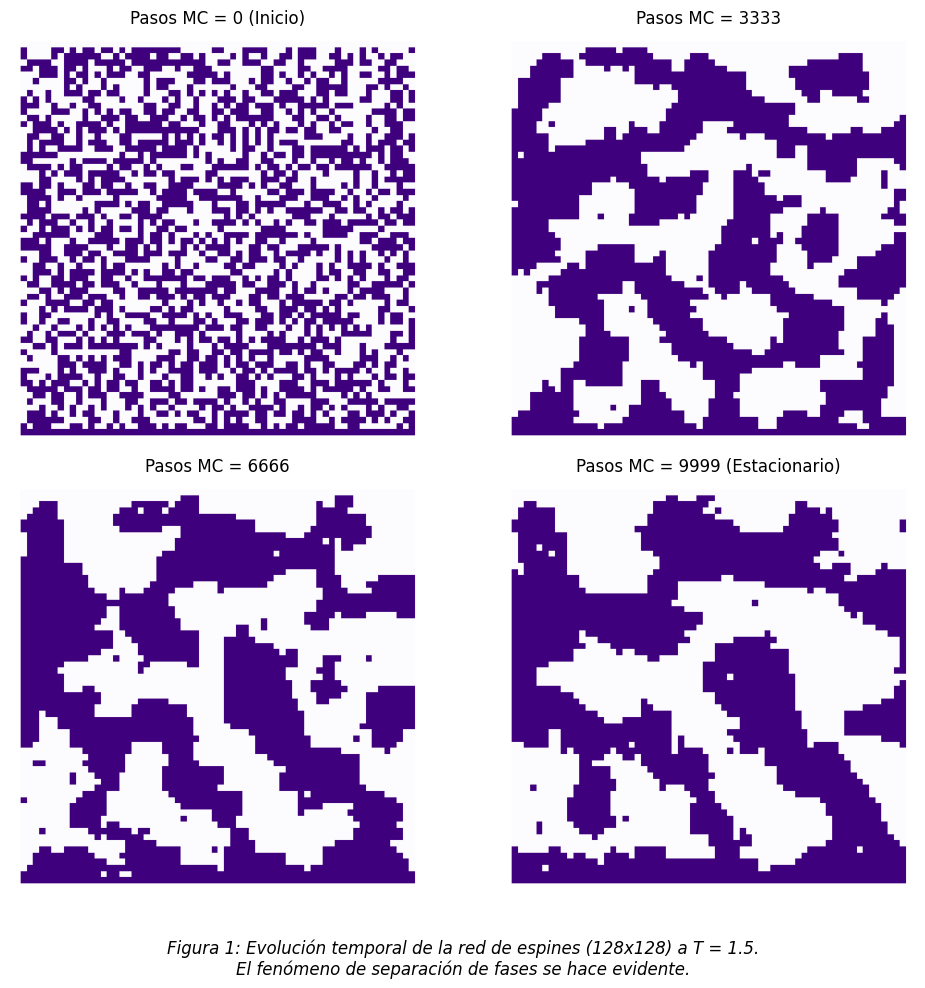

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Crear una figura con una cuadrícula de 2x2
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Cargar las imágenes (asegúrate de que los nombres coinciden con los que subiste)
img0 = mpimg.imread('/fotograma_0.png')
img1 = mpimg.imread('/fotograma_3333.png')
img2 = mpimg.imread('/fotograma_6666.png')
img3 = mpimg.imread('/fotograma_9999.png')

# Colocar cada imagen en su panel y quitar los ejes
axs[0, 0].imshow(img0)
axs[0, 0].axis('off')
axs[0, 0].set_title('Pasos MC = 0 (Inicio)')

axs[0, 1].imshow(img1)
axs[0, 1].axis('off')
axs[0, 1].set_title('Pasos MC = 3333')

axs[1, 0].imshow(img2)
axs[1, 0].axis('off')
axs[1, 0].set_title('Pasos MC = 6666')

axs[1, 1].imshow(img3)
axs[1, 1].axis('off')
axs[1, 1].set_title('Pasos MC = 9999 (Estacionario)')
# Primero ajustamos el layout
plt.tight_layout()

# Hacemos espacio explícitamente en la parte inferior (10% de la figura)
plt.subplots_adjust(bottom=0.1)

# Añadimos el texto en ese hueco que hemos dejado libre
fig.text(0.5, 0.02, 'Figura 1: Evolución temporal de la red de espines (128x128) a T = 1.5.\nEl fenómeno de separación de fases se hace evidente.',
         ha='center', fontsize=12, fontstyle='italic')

plt.show()

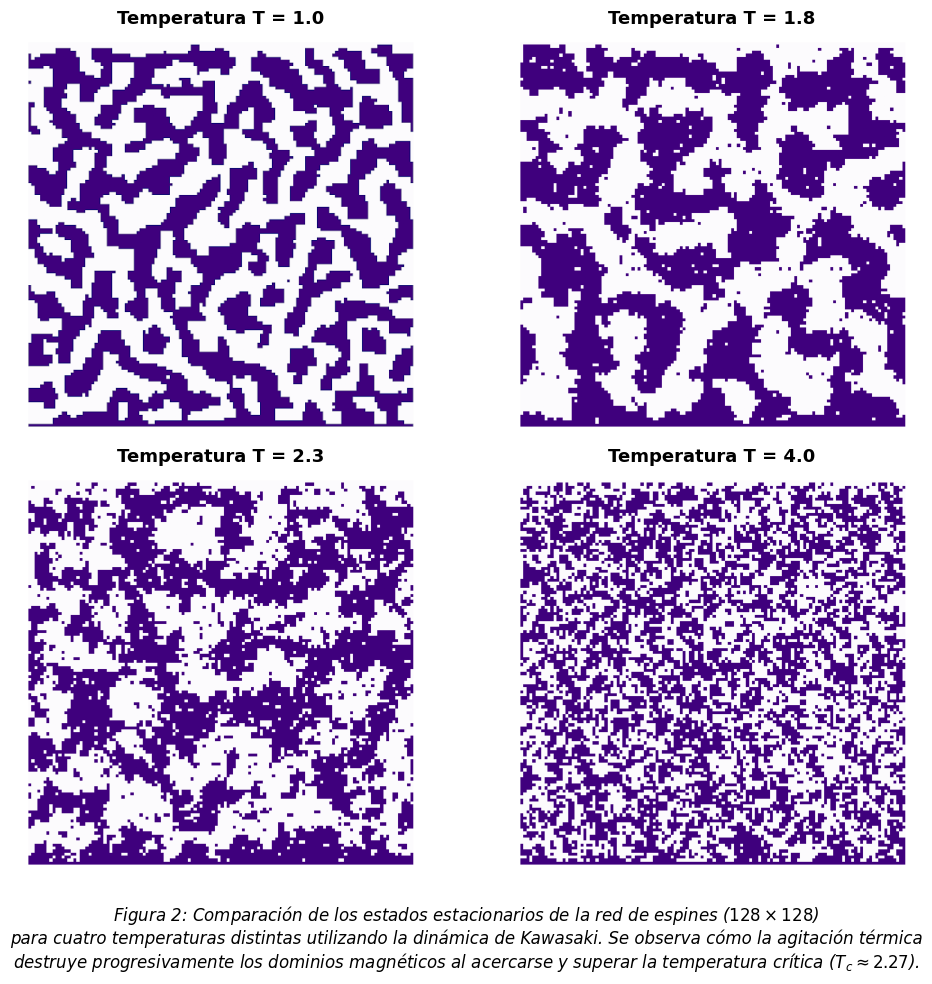

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Crear una figura con una cuadrícula de 2x2
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# --- PON AQUÍ LOS NOMBRES DE TUS 4 IMÁGENES PNG ---
img_T1 = mpimg.imread('/fotograma__1.png')
img_T2 = mpimg.imread('/.fotogramas_T1.8.png') # o la temperatura que hayas usado
img_T3 = mpimg.imread('/fotogramas_T2.8.png')
img_T4 = mpimg.imread('/.fotogramas_T4.0.png')

# Colocar cada imagen en su panel, quitar los ejes y poner título
axs[0, 0].imshow(img_T1)
axs[0, 0].axis('off')
axs[0, 0].set_title('Temperatura T = 1.0', fontsize=13, fontweight='bold')

axs[0, 1].imshow(img_T2)
axs[0, 1].axis('off')
axs[0, 1].set_title('Temperatura T = 1.8', fontsize=13, fontweight='bold')

axs[1, 0].imshow(img_T3)
axs[1, 0].axis('off')
axs[1, 0].set_title('Temperatura T = 2.3', fontsize=13, fontweight='bold')

axs[1, 1].imshow(img_T4)
axs[1, 1].axis('off')
axs[1, 1].set_title('Temperatura T = 4.0', fontsize=13, fontweight='bold')

# Ajustar el layout para que no se apriete todo
plt.tight_layout()

# Dejar margen abajo (12%) para que quepa el texto sin pisar las imágenes
plt.subplots_adjust(bottom=0.12)

# Añadir el pie de foto general
pie_de_foto = (
    "Figura 2: Comparación de los estados estacionarios de la red de espines ($128 \\times 128$)\n"
    "para cuatro temperaturas distintas utilizando la dinámica de Kawasaki. Se observa cómo la agitación térmica\n"
    "destruye progresivamente los dominios magnéticos al acercarse y superar la temperatura crítica ($T_c \\approx 2.27$)."
)
fig.text(0.5, 0.03, pie_de_foto, ha='center', fontsize=12, fontstyle='italic', wrap=True)

# Mostrar la figura final
plt.show()



#2. Curva de Magnetización por Dominios

En la dinámica de Kawasaki, el mecanismo de intercambio de espines garantiza que la magnetización total del sistema se conserve estrictamente a lo largo del tiempo. Puesto que inicializamos la simulación con el mismo número de espines positivos y negativos (magnetización global nula), un promedio espacial estándar siempre daría cero y ocultaría la existencia de la transición de fase.

Para capturar correctamente el parámetro de orden del sistema, se introduce el concepto de **magnetización por dominios**. Gracias a las condiciones de contorno fijas en el eje $y$ (borde superior anclado a espines $-1$ y borde inferior a $+1$), obligamos al sistema a que, a bajas temperaturas, la fase negativa se agrupe arriba y la positiva abajo. El cálculo se realiza mediante los siguientes pasos:

1. **División Espacial:** Se divide la red transversalmente en dos mitades iguales (superior e inferior).
2. **Magnetización Local:** Se suma el valor de todos los espines en la mitad superior y se divide entre el número de partículas de esa mitad ($N^2 / 2$) para obtener $m_{sup}$. Se procede de forma idéntica con la mitad inferior para hallar $m_{inf}$.
3. **Parámetro de Orden:** La magnetización por dominios del sistema, $m_{dom}$, se define promediando el valor absoluto de la magnetización de ambas regiones:
   $$m_{dom} = \frac{|m_{sup}| + |m_{inf}|}{2}$$

Este cálculo se realiza en cada paso Monte Carlo una vez que el sistema ha termalizado. Promediando estos valores a lo largo del tiempo, obtenemos la magnetización media esperada $\langle m_{dom} \rangle$ para una temperatura $T$ dada.

**Estudio de los Efectos de Tamaño Finito**
Para comprender cómo evoluciona el sistema hacia el límite termodinámico ($N \to \infty$), se superponen las curvas de magnetización para redes de distintos tamaños ($N=32$, $N=64$ y $N=128$). Al graficar estas curvas, se espera observar lo siguiente:

* **Régimen de baja temperatura ($T < T_c$):** El sistema mantiene fases bien separadas, por lo que $m_{dom} \approx 1$.
* **Entorno de la temperatura crítica ($T \approx 2.27$):** Se produce una caída abrupta en la magnetización. Cuanto mayor es el tamaño del sistema ($N=128$), más vertical y pronunciada es esta caída, evidenciando la discontinuidad matemática propia de una transición de fase continua real.
* **Régimen de alta temperatura ($T > T_c$):** La elevada agitación térmica destruye los dominios por completo, mezclando los espines en ambas mitades y llevando el parámetro de orden a $m_{dom} \approx 0$.

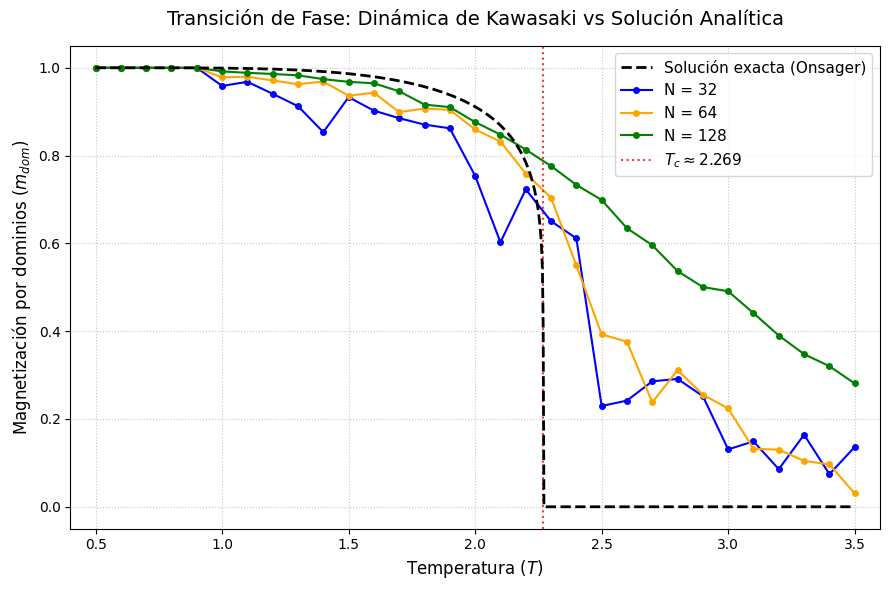

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ========================================
# Parámetros de la gráfica
# ========================================
archivos = [
    ("magnetizacion_32.dat", "N = 32", "blue"),
    ("magnetizacion_64.dat", "N = 64", "orange"),
    ("magnetizacion_128.dat", "N = 128", "green")
]

plt.figure(figsize=(9, 6))

# ========================================
# 1. Curva Teórica de Onsager-Yang
# ========================================
# Creamos un vector de temperaturas muy denso para que la curva sea suave
T_teo = np.linspace(0.5, 3.5, 1000)
T_c = 2.0 / np.log(1.0 + np.sqrt(2.0)) # Valor exacto: ~2.269

# Inicializamos la magnetización teórica a cero
m_teo = np.zeros_like(T_teo)

# Solo calculamos la fórmula para T < Tc (donde hay orden)
mascara = T_teo < T_c
m_teo[mascara] = (1.0 - np.sinh(2.0 / T_teo[mascara])**(-4))**(1.0 / 8.0)

# Dibujamos la curva analítica en negro punteado
plt.plot(T_teo, m_teo, '--', color='black', linewidth=2, zorder=5, label='Solución exacta (Onsager)')

# ========================================
# 2. Lectura de datos experimentales
# ========================================
for archivo, etiqueta, color in archivos:
    if os.path.exists(archivo):
        T, m_dom = np.loadtxt(archivo, skiprows=1, unpack=True)
        plt.plot(T, m_dom, marker='o', markersize=4, linestyle='-', color=color, label=etiqueta)
    else:
        print(f"Aviso: No se encontró el archivo '{archivo}'.")

# ========================================
# Formato de la gráfica
# ========================================
plt.title("Transición de Fase: Dinámica de Kawasaki vs Solución Analítica", fontsize=14, pad=15)
plt.xlabel("Temperatura ($T$)", fontsize=12)
plt.ylabel(r"Magnetización por dominios ($m_{dom}$)", fontsize=12)

plt.axvline(x=T_c, color='red', linestyle=':', alpha=0.8, label=rf'$T_c \approx {T_c:.3f}$')

plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0.4, 3.6)
plt.ylim(-0.05, 1.05)
plt.tight_layout()

plt.savefig("curva_magnetizacion_con_teorica.png", dpi=300)
plt.show()

# 3. Perfil de Densidad: Analogía con el Gas de Red

Una de las aplicaciones más directas de la dinámica de Kawasaki es su equivalencia matemática con el modelo del **gas de red** (lattice gas). En esta interpretación física, la matriz no representa una red de dipolos magnéticos, sino un volumen espacial fragmentado en celdas que pueden estar ocupadas por una partícula o estar vacías:

* **Espín $+1$:** Representa una posición ocupada por una partícula.
* **Espín $-1$:** Representa una posición vacía (un hueco).

Mediante esta transformación, podemos definir la densidad local de partículas $\rho$ en una posición dada en función del valor del espín $s$:
$$\rho = \frac{s + 1}{2}$$

El objetivo de este apartado es estudiar el perfil de densidad macroscópico a lo largo del eje vertical $y$. Debido a las condiciones de contorno fijas (espines $-1$ en el borde superior y $+1$ en el inferior), el sistema se ve forzado a mantener una región de "vacío" en la parte superior y un "fluido denso" en la parte inferior, simulando el comportamiento de un líquido en coexistencia con su vapor bajo gravedad.

**Metodología de Cálculo**
Para obtener el perfil de densidad continuo $\rho(y)$, el algoritmo promedia el valor de los espines en cada fila horizontal (eje $x$) para cada paso de tiempo. Una vez termalizado el sistema, se realiza un promedio estadístico temporal a lo largo de los miles de pasos Monte Carlo.

**Evolución Térmica de la Interfaz**
Al representar gráficamente la densidad frente a la altura $y$ para distintas temperaturas, ilustramos la evolución de la interfaz entre el líquido y el vapor:

* **Régimen de bajas temperaturas ($T = 1.0$):** La falta de agitación térmica mantiene las fases rígidamente separadas. El perfil mostrará un escalón muy abrupto en el centro de la red, pasando casi de forma instantánea de $\rho = 0$ a $\rho = 1$.
* **Régimen intermedio y crítico ($T = 1.8$, $T = 2.3$):** La energía térmica permite la difusión de partículas hacia la zona vacía. La interfaz experimenta un ensanchamiento progresivo, y el escalón abrupto se suaviza adoptando la forma característica de un perfil sigmoide (tangente hiperbólica).
* **Régimen de altas temperaturas ($T = 3.5$):** La entropía domina por completo la termodinámica del sistema. Las partículas y los huecos se mezclan formando un gas homogéneo, y la densidad media fluctúa en torno a $\rho \approx 0.5$ en el interior del sistema, desviándose únicamente en las inmediaciones de los bordes artificialmente fijados.

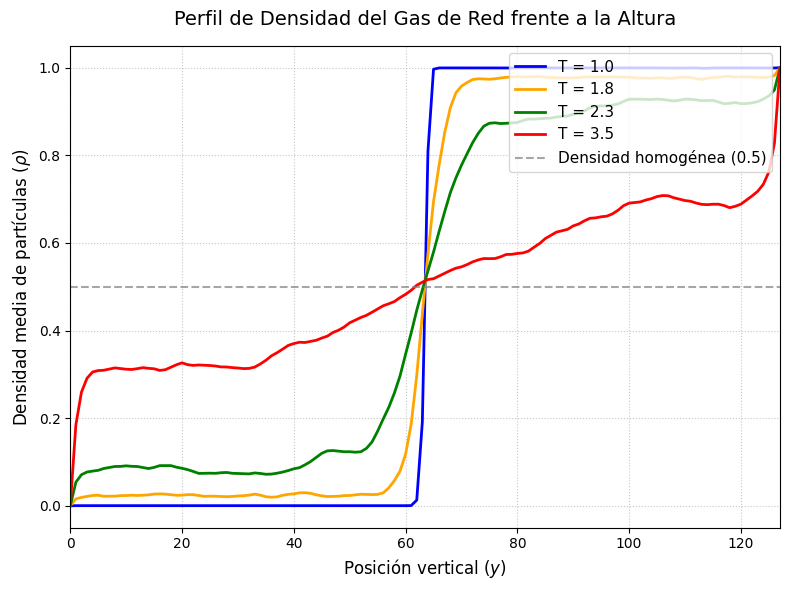

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import os

archivos = [
    ("magnetizacion_32.dat", "N = 32", "blue"),
    ("magnetizacion_64.dat", "N = 64", "orange"),
    ("magnetizacion_128.dat", "N = 128", "green")
]

plt.figure(figsize=(9, 6))

# 1. Curva Teórica (Onsager-Yang)
T_teo = np.linspace(0.5, 3.5, 1000)
T_c = 2.0 / np.log(1.0 + np.sqrt(2.0))
m_teo = np.zeros_like(T_teo)
mascara = T_teo < T_c
m_teo[mascara] = (1.0 - np.sinh(2.0 / T_teo[mascara])**(-4))**(1.0 / 8.0)
plt.plot(T_teo, m_teo, '--', color='black', linewidth=2, zorder=5, label='Solución exacta (Onsager)')

# 2. Datos Experimentales con Barras de Error
for archivo, etiqueta, color in archivos:
    if os.path.exists(archivo):
        # Desempaquetamos 3 columnas: T, media y el error calculado
        T, m_dom, error = np.loadtxt(archivo, skiprows=1, unpack=True)

        # Función errorbar dibuja el punto, la línea y la barra de incertidumbre
        plt.errorbar(T, m_dom, yerr=error, fmt='-o', markersize=4, color=color,
                     capsize=3, elinewidth=1.5, label=etiqueta)
    else:
        print(f"Aviso: No se encontró el archivo '{archivo}'.")

# 3. Formato
plt.title("Transición de Fase con Barras de Error (Dinámica de Kawasaki)", fontsize=14, pad=15)
plt.xlabel("Temperatura ($T$)", fontsize=12)
plt.ylabel(r"Magnetización por dominios ($m_{dom}$)", fontsize=12)
plt.axvline(x=T_c, color='red', linestyle=':', alpha=0.8, label=rf'$T_c \approx {T_c:.3f}$')

plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(0.4, 3.6)
plt.ylim(-0.05, 1.05)
plt.tight_layout()

plt.savefig("curva_magnetizacion_errores.png", dpi=300)
plt.show()-

#Anexo (Códigos de C++)

## 1.Modelo de Ising (Kawasaki)

In [2]:
%%writefile kawasaki.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <cstdlib>
#include <fstream>
#include <algorithm> // Necesario para std::shuffle
#include <random>    // Necesario para el generador aleatorio

using namespace std;

int main() {
    int dim = 32;       // Aumentamos a 32x32 como sugiere el PDF
    int iter = 1000;     // Pasos Monte Carlo
    float T = 1.0;      // Temperatura
    unsigned int seed = 1649176165;

    std::srand(seed);
    std::mt19937 g(seed); // Generador para mezclar bien los espines iniciales

    ofstream data_anim("ising_kawasaki.dat");

    // * 1. CONFIGURACIÓN INICIAL (Magnetización Nula y Bordes fijos) * //
    vector<vector<int>> s(dim, vector<int>(dim));

    // Para asegurar magnetización nula exacta en el centro, creamos un vector
    // con la mitad de espines a +1 y la otra mitad a -1, y lo barajamos.
    vector<int> espines_activos;
    int num_activos = (dim - 2) * dim;
    for (int k = 0; k < num_activos; k++) {
        if (k < num_activos / 2) espines_activos.push_back(1);
        else espines_activos.push_back(-1);
    }
    std::shuffle(espines_activos.begin(), espines_activos.end(), g);

    // Asignamos a la matriz
    int c = 0;
    for (int i = 0; i < dim; i++) {
        for (int j = 0; j < dim; j++) {
            if (i == 0) {
                s[i][j] = -1; // Borde superior fijo (Figura 1)
            } else if (i == dim - 1) {
                s[i][j] = 1;  // Borde inferior fijo (Figura 1)
            } else {
                s[i][j] = espines_activos[c++]; // Región interior
            }

            data_anim << s[i][j];
            if (j < dim - 1) data_anim << ",";
        }
        data_anim << "\n";
    }
    data_anim << "\n";

    // * 2. ALGORITMO MONTE CARLO (Dinámica de Kawasaki) * //
    for (int k = 0; k < iter; k++) {
        for (int l = 0; l < dim * dim; l++) {
            // Seleccionamos espín aleatorio SOLO en la región activa (filas 1 a dim-2)
            int i = std::rand() % (dim - 2) + 1;
            int j = std::rand() % dim;

            // Elegimos un vecino al azar (0: arriba, 1: abajo, 2: izq, 3: der)
            int dir = std::rand() % 4;
            int ni = i, nj = j;

            if (dir == 0) ni = i - 1;
            else if (dir == 1) ni = i + 1;
            else if (dir == 2) nj = (j - 1 + dim) % dim; // Condición periódica en X
            else if (dir == 3) nj = (j + 1) % dim;       // Condición periódica en X

            // Si el vecino que hemos elegido es uno de los bordes fijos, no podemos intercambiar
            if (ni == 0 || ni == dim - 1) continue;

            // Si los espines son iguales, intercambiarlos no hace nada, pasamos al siguiente
            if (s[i][j] == s[ni][nj]) continue;

            // Calculamos hA y hB (la suma de los 4 vecinos de cada posición)
            int hA = s[i-1][j] + s[i+1][j] + s[i][(j-1+dim)%dim] + s[i][(j+1)%dim];
            int hB = s[ni-1][nj] + s[ni+1][nj] + s[ni][(nj-1+dim)%dim] + s[ni][(nj+1)%dim];

            // * 3. APLICAMOS LA FÓRMULA DE ENERGÍA DEDUCIDA * //
            int sA = s[i][j];
            float dE = 2 * sA * (hA - hB) + 4.0f;

            // * 4. CONDICIÓN DE METROPOLIS PARA EL INTERCAMBIO * //
            if (dE <= 0) {
                // Aceptamos el intercambio directamente
                s[i][j] = s[ni][nj];
                s[ni][nj] = sA;
            } else {
                float p = std::exp(-dE / T);
                float r = static_cast<float>(std::rand()) / RAND_MAX;
                if (r < p) {
                    // Aceptamos el intercambio por probabilidad
                    s[i][j] = s[ni][nj];
                    s[ni][nj] = sA;
                }
            }
        }

        // GUARDAMOS EL FOTOGRAMA
        for (int i = 0; i < dim; i++) {
            for (int j = 0; j < dim; j++) {
                data_anim << s[i][j];
                if (j < dim - 1) data_anim << ",";
            }
            data_anim << "\n";
        }
        if (k < iter - 1) data_anim << "\n";
    }

    data_anim.close();
    return 0;
}

Overwriting kawasaki.cpp


In [3]:
# Compilamos el código con máxima optimización (-O3)
!g++ -O3 kawasaki.cpp -o simular_kawasaki

# Ejecutamos la simulación
!./simular_kawasaki

## 2. Magnetización

In [17]:
%%writefile magnetizacion.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <cstdlib>
#include <fstream>
#include <random>

using namespace std;

int main() {
    int dim = 64;                  // Cambiar a 64 y 128
    int mcs_termalizacion = 40000; // Mantenemos tu termalización larga
    int mcs_medida = 10000;
    unsigned int seed = 1649176165;

    std::mt19937 g(seed);

    ofstream data_out("magnetizacion_64.dat");
    data_out << "T\tm_dom\terror\n"; // ¡Nueva cabecera de 3 columnas!

    for (float T = 0.5f; T <= 3.5f; T += 0.1f) {

        // 1. INICIALIZACIÓN ORDENADA
        vector<vector<int>> s(dim, vector<int>(dim));
        for (int i = 0; i < dim; i++) {
            for (int j = 0; j < dim; j++) {
                if (i < dim / 2) s[i][j] = -1;
                else s[i][j] = 1;
            }
        }

        // 2. TERMALIZACIÓN
        for (int k = 0; k < mcs_termalizacion; k++) {
            for (int l = 0; l < dim * dim; l++) {
                int i = std::rand() % (dim - 2) + 1;
                int j = std::rand() % dim;
                int dir = std::rand() % 4;
                int ni = i, nj = j;

                if (dir == 0) ni = i - 1;
                else if (dir == 1) ni = i + 1;
                else if (dir == 2) nj = (j - 1 + dim) % dim;
                else if (dir == 3) nj = (j + 1) % dim;

                if (ni == 0 || ni == dim - 1) continue;
                if (s[i][j] == s[ni][nj]) continue;

                int hA = s[i-1][j] + s[i+1][j] + s[i][(j-1+dim)%dim] + s[i][(j+1)%dim];
                int hB = s[ni-1][nj] + s[ni+1][nj] + s[ni][(nj-1+dim)%dim] + s[ni][(nj+1)%dim];

                int sA = s[i][j];
                float dE = 2 * sA * (hA - hB) + 4.0f;

                if (dE <= 0 || (static_cast<float>(std::rand()) / RAND_MAX) < std::exp(-dE / T)) {
                    s[i][j] = s[ni][nj];
                    s[ni][nj] = sA;
                }
            }
        }

        // 3. MEDIDA DEL OBSERVABLE Y SU CUADRADO
        float suma_m_dom = 0;
        float suma_m_dom_cuadrado = 0; // NUEVO: para la varianza

        for (int k = 0; k < mcs_medida; k++) {
            for (int l = 0; l < dim * dim; l++) {
                int i = std::rand() % (dim - 2) + 1;
                int j = std::rand() % dim;
                int dir = std::rand() % 4;
                int ni = i, nj = j;

                if (dir == 0) ni = i - 1;
                else if (dir == 1) ni = i + 1;
                else if (dir == 2) nj = (j - 1 + dim) % dim;
                else if (dir == 3) nj = (j + 1) % dim;

                if (ni == 0 || ni == dim - 1) continue;
                if (s[i][j] == s[ni][nj]) continue;

                int hA = s[i-1][j] + s[i+1][j] + s[i][(j-1+dim)%dim] + s[i][(j+1)%dim];
                int hB = s[ni-1][nj] + s[ni+1][nj] + s[ni][(nj-1+dim)%dim] + s[ni][(nj+1)%dim];

                int sA = s[i][j];
                float dE = 2 * sA * (hA - hB) + 4.0f;

                if (dE <= 0 || (static_cast<float>(std::rand()) / RAND_MAX) < std::exp(-dE / T)) {
                    s[i][j] = s[ni][nj];
                    s[ni][nj] = sA;
                }
            }

            float m_sup = 0, m_inf = 0;
            for (int i = 0; i < dim / 2; i++) {
                for (int j = 0; j < dim; j++) m_sup += s[i][j];
            }
            for (int i = dim / 2; i < dim; i++) {
                for (int j = 0; j < dim; j++) m_inf += s[i][j];
            }

            int particulas = (dim / 2) * dim;
            m_sup /= particulas;
            m_inf /= particulas;

            float m_dom_actual = (std::abs(m_sup) + std::abs(m_inf)) / 2.0f;

            // Acumulamos el valor y su cuadrado
            suma_m_dom += m_dom_actual;
            suma_m_dom_cuadrado += m_dom_actual * m_dom_actual;
        }

        // 4. CÁLCULO DE MEDIA Y ERROR ESTADÍSTICO
        float m_media = suma_m_dom / mcs_medida;
        float m_cuadrado_media = suma_m_dom_cuadrado / mcs_medida;

        // Varianza = <m^2> - <m>^2 (usamos abs por si hay errores de precisión de coma flotante)
        float varianza = std::abs(m_cuadrado_media - (m_media * m_media));

        // Error de la media (Desviación típica / sqrt(N))
        float error = std::sqrt(varianza / mcs_medida);

        data_out << T << "\t" << m_media << "\t" << error << "\n";
        std::cout << "Calculado T = " << T << " | m_dom = " << m_media << " +- " << error << std::endl;
    }

    data_out.close();
    return 0;
}

Overwriting magnetizacion.cpp


In [ ]:
# Compilamos el código con máxima optimización (-O3)
!g++ -O3 magnetizacion.cpp -o simular_magnetizacion

# Ejecutamos la simulación
!./simular_magnetizacion

Calculado T = 0.5 | m_dom = 1 +- 0
Calculado T = 0.6 | m_dom = 1 +- 0
Calculado T = 0.7 | m_dom = 1 +- 0
Calculado T = 0.8 | m_dom = 1 +- 0
Calculado T = 0.9 | m_dom = 0.999938 +- 0


##3 Perfil de densidad

In [11]:
%%writefile densidad.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <cstdlib>
#include <fstream>
#include <string>
#include <random>

using namespace std;

int main() {
    int dim = 128;                 // Usar 128 para que la curva sea suave
    int mcs_termalizacion = 40000; // Muchos pasos para equilibrar bien
    int mcs_medida = 10000;
    unsigned int seed = 123456789;

    std::mt19937 g(seed);

    // Seleccionamos las 4 temperaturas que cuentan la historia térmica
    vector<float> temperaturas = {1.0f, 1.8f, 2.3f, 3.5f};

    for (float T : temperaturas) {
        cout << "Calculando perfil para T = " << T << "..." << endl;

        // 1. INICIALIZACIÓN ORDENADA POR DOMINIOS
        vector<vector<int>> s(dim, vector<int>(dim));
        for (int i = 0; i < dim; i++) {
            for (int j = 0; j < dim; j++) {
                if (i < dim / 2) s[i][j] = -1;
                else s[i][j] = 1;
            }
        }

        // 2. TERMALIZACIÓN
        for (int k = 0; k < mcs_termalizacion; k++) {
            for (int l = 0; l < dim * dim; l++) {
                int i = std::rand() % (dim - 2) + 1;
                int j = std::rand() % dim;
                int dir = std::rand() % 4;
                int ni = i, nj = j;

                if (dir == 0) ni = i - 1;
                else if (dir == 1) ni = i + 1;
                else if (dir == 2) nj = (j - 1 + dim) % dim;
                else if (dir == 3) nj = (j + 1) % dim;

                if (ni == 0 || ni == dim - 1) continue;
                if (s[i][j] == s[ni][nj]) continue;

                int hA = s[i-1][j] + s[i+1][j] + s[i][(j-1+dim)%dim] + s[i][(j+1)%dim];
                int hB = s[ni-1][nj] + s[ni+1][nj] + s[ni][(nj-1+dim)%dim] + s[ni][(nj+1)%dim];
                int sA = s[i][j];
                float dE = 2 * sA * (hA - hB) + 4.0f;

                if (dE <= 0 || (static_cast<float>(std::rand()) / RAND_MAX) < std::exp(-dE / T)) {
                    s[i][j] = s[ni][nj];
                    s[ni][nj] = sA;
                }
            }
        }

        // 3. MEDIDA DEL PERFIL DE DENSIDAD
        // Vector para acumular la densidad en cada fila
        vector<float> densidad_fila(dim, 0.0f);

        for (int k = 0; k < mcs_medida; k++) {
            // Un paso MC de Kawasaki
            for (int l = 0; l < dim * dim; l++) {
                int i = std::rand() % (dim - 2) + 1;
                int j = std::rand() % dim;
                int dir = std::rand() % 4;
                int ni = i, nj = j;

                if (dir == 0) ni = i - 1;
                else if (dir == 1) ni = i + 1;
                else if (dir == 2) nj = (j - 1 + dim) % dim;
                else if (dir == 3) nj = (j + 1) % dim;

                if (ni == 0 || ni == dim - 1) continue;
                if (s[i][j] == s[ni][nj]) continue;

                int hA = s[i-1][j] + s[i+1][j] + s[i][(j-1+dim)%dim] + s[i][(j+1)%dim];
                int hB = s[ni-1][nj] + s[ni+1][nj] + s[ni][(nj-1+dim)%dim] + s[ni][(nj+1)%dim];
                int sA = s[i][j];
                float dE = 2 * sA * (hA - hB) + 4.0f;

                if (dE <= 0 || (static_cast<float>(std::rand()) / RAND_MAX) < std::exp(-dE / T)) {
                    s[i][j] = s[ni][nj];
                    s[ni][nj] = sA;
                }
            }

            // Tras barrer la red, sumamos la densidad actual de cada fila
            for (int i = 0; i < dim; i++) {
                float densidad_actual = 0;
                for (int j = 0; j < dim; j++) {
                    // Convertimos el espín a densidad de partículas (0 o 1)
                    densidad_actual += (s[i][j] + 1.0f) / 2.0f;
                }
                // Promediamos por el ancho de la red y acumulamos
                densidad_fila[i] += densidad_actual / dim;
            }
        }

        // 4. GUARDAR DATOS
        string filename = "perfil_densidad_T" + to_string(T) + ".dat";
        ofstream data_out(filename);
        data_out << "y\tDensidad\n";

        for (int i = 0; i < dim; i++) {
            // Dividimos entre las medidas para obtener la media estadística
            data_out << i << "\t" << (densidad_fila[i] / mcs_medida) << "\n";
        }
        data_out.close();
    }

    cout << "Todos los perfiles calculados con exito." << endl;
    return 0;
}

Writing densidad.cpp


In [12]:
# Compilamos el código con máxima optimización (-O3)
!g++ -O3 densidad.cpp -o simular_densidad

# Ejecutamos la simulación
!./simular_densidad

Calculando perfil para T = 1...
Calculando perfil para T = 1.8...
Calculando perfil para T = 2.3...
Calculando perfil para T = 3.5...
Todos los perfiles calculados con exito.
